# Hand-In Assignment: Hilary mid-term

This assignment has two parts. 

In the first part you carry out some hypothesis tests; this is designed for you to practice both the process of running the different tests, and to make sure you understand the choices you are making when running tests.

The second part, 'revision', targets some Python syntax and (mainly) some concepts that I want to make sure everyone has securely grasped. The answers to all conceptual questions can be found in the lectures and reading; searching for them is good revision!

Overall, the idea of this assignment is to help you consolidate what you learned in the first three blocks of the course. Please remember that searching for the answers (in the lecture notes etc) and trying things til it works (for coding) is part of the learning process; you are *supposed* to need to do that rather than having all the answers at your fingertips.

If you get stuck on something, try the lecture notes, try the reading, and try Google as there are many helpful 'how to' blogs out there and many blogs explaining statistical concepts. If you still are stuck, ask your tutor!

In [87]:
# Set-up Python libraries - you need to run this but you don't need to change it
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd
import seaborn as sns
sns.set_theme(style='white')
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Part 1 - data analysis exercises

In these questions you need to carry out various statistical tests. Please read the questions carefully and answer all parts - in particular if you are asked to *comment* on your results you must comment; this usually means interpret the results in plain English.

## Question 1 - Cloud seeding

Cloud seeding is a process by which a light aircraft dumps particulate matter into a cloud in the hope of causing precipitation (rain). The file CloudSeeding.csv contains standardized rainfall yield measures for seeded and unseeded clouds. These are real data from a study in 1975.

As a side note, cloud seeding does work and <a href='https://www.independent.co.uk/sport/olympics/how-beijing-used-rockets-to-keep-opening-ceremony-dry-890294.html'> is used to *prevent* rain </a> during important outdoor events - although it mimght have the side effect of causing a deluge nearby!

**a)  Download the data file and load the data into a `Pandas` dataframe called `clouds`**

In [88]:
clouds = pd.read_csv('https://raw.githubusercontent.com/jillxoreilly/StatsCourseBook_2025/main/data/cloudSeeding.csv')
clouds

,status,rainfall
0,Unseeded,1202.6
1,Unseeded,830.1
2,Unseeded,372.4
3,Unseeded,345.5
4,Unseeded,321.2
5,Unseeded,244.3
6,Unseeded,163.0
7,Unseeded,147.8
8,Unseeded,95.0
9,Unseeded,87.0


**b) Plot the data for seeded and unseeded clouds in a way that shows the distribution of rainfall yields**

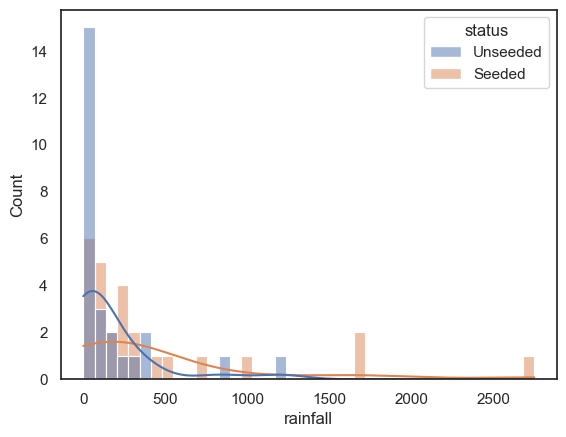

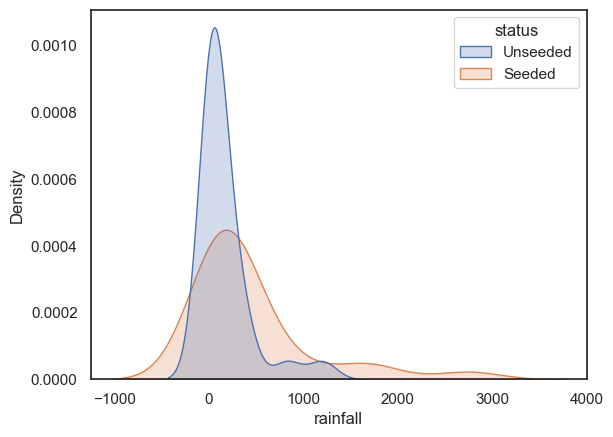

In [89]:
sns.histplot(clouds, x='rainfall', hue='status', kde=True, bins=40)
plt.show()
sns.kdeplot(clouds, x='rainfall', hue='status', fill=True)
plt.show()

**c) Calculate the parameters of the best fitting Normal distributions for seeded and unseeded clouds respectively**

In [90]:
std_seeded = clouds[clouds['status'] == 'Seeded']['rainfall'].std()
std_unseeded = clouds[clouds['status'] == 'Unseeded']['rainfall'].std()


mean_seeded = clouds[clouds['status'] == 'Seeded']['rainfall'].mean()
mean_unseeded = clouds[clouds['status'] == 'Unseeded']['rainfall'].mean()

print(f"seeded: mean={mean_seeded:.2f}, std={std_seeded:.2f}\n"
      f"unseeded: mean={mean_unseeded:.2f}, std={std_unseeded:.2f}")

seeded: mean=441.98, std=650.79
unseeded: mean=164.59, std=278.43


State the parameters here


**d) Is a normal distribution a good fit to the data?**

*The here we overlay the best fitting normal on the data KDE plot:*

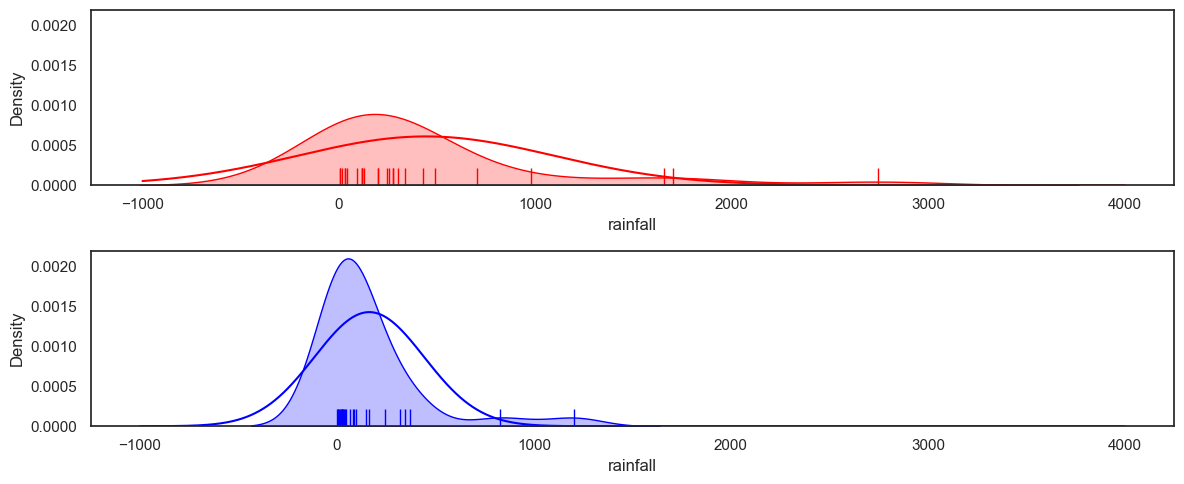

In [91]:
plt.figure(figsize=(12, 5))

seeded=clouds.query('status=="Seeded"').rainfall
unseeded=clouds.query('status=="Unseeded"').rainfall

# seeded clouds
plt.subplot(2,1,1)
x=range(-1000,4000)
y = stats.norm.pdf(x,seeded.mean(),seeded.std())
plt.plot(x,y,color=(1,0,0))
sns.kdeplot(data=seeded, color=[1,0,0], fill=True)
sns.rugplot(data=seeded, color=[1,0,0], height=0.1)
plt.ylim([0,0.0022])

# unseeded clouds
plt.subplot(2,1,2)
x=range(-1000,4000)
y = stats.norm.pdf(x,unseeded.mean(),unseeded.std())
plt.plot(x,y,color=(0,0,1))
sns.kdeplot(data=unseeded, color=[0,0,1], fill=True)
sns.rugplot(data=unseeded, color=[0,0,1], height=0.1)
plt.ylim([0,0.0022])

plt.tight_layout()
plt.show()

*Based on the plot above, the data are not well fitted by a normal distribution. Comment on the what you can see in the graph that suggests the normal distribution is a poor fit.*

The true distribution is heavily skewed to the right as precipitation cannot be less than zero and values closer to zero are more common. A normal distribution that is symmetric thus cannot be a good fit for the data. In the plot, we see that the peaks do not line up, more specifically that the fitted normal distribution is to the right, owing to its mean that cannot be zero if all values are > 0. It is apparent that a normal distribution is not the model to choose for this data.

**e) Conduct three statistical tests of the researcher’s hypothesis, based on:**

*I.	Assumption of normality*

*II.	Permutation*

*III.	Ranked values*

*… in each case you should:*
* State the null and alternative hypothesis and the alpha value
* Report appropriate descriptive statistics for the test in question
* Carry out the test
* State the results of the test including the test statistic and p value. For the t-test, degrees of freedom should also be stated.
* Report your practical conclusion in plain English



**For I. (t) and II. (permutation) tests, I will define the following**:
- null hypothesis: the means of both seeded and unseeded rainfall values are the same, $μ_{seeded} =  μ_{unseeded}$
- alternative hypothesis: the mean of seeded rainfall values is greater, $μ_{seeded} > μ_{unseeded}$ (upper tail)
- alpha value: 0.05

**For III. (rank based), I will define:**
- null hypothesis: the *distributions* of both seeded and unseeded rainfall values are the same
- alternative hypothesis: the seeded rainfall values tend to be greater than unseeded
- alpha value: 0.05

In [92]:
ttest = stats.ttest_ind(clouds.query('status=="Seeded"').rainfall,
                clouds.query('status=="Unseeded"').rainfall, 
                alternative='greater')

print("  I. Assumption of normality (independent t test): p-value:", round(ttest.pvalue, 4), ", degrees of freedom:", ttest.df)

permutation = stats.permutation_test(
                (clouds.query('status=="Seeded"').rainfall,
                clouds.query('status=="Unseeded"').rainfall),
                lambda s, u: np.mean(s) - np.mean(u),
                permutation_type='independent', 
                alternative='greater', 
                n_resamples=10000)

print(" II. Permutation test (independent):               p-value:", round(permutation.pvalue, 4))

ranked = stats.mannwhitneyu(
            clouds.query('status=="Seeded"').rainfall,
            clouds.query('status=="Unseeded"').rainfall,
            alternative='greater',
            method='auto')

print("III. Ranked values (independent / Mann–Whitney U): p-value:", round(ranked.pvalue, 4))

  I. Assumption of normality (independent t test): p-value: 0.0256 , degrees of freedom: 50.0
 II. Permutation test (independent):               p-value: 0.0209
III. Ranked values (independent / Mann–Whitney U): p-value: 0.0069


For all three tests, we can conclude at α=0.05 sufficient evidence to reject the null hypothesis. This means that seeded clouds have a  statistically significant increase in rainfall.

**f) Comment on the relative merits of each possible choice of test for this dataset.**

For all three tests, I have chosen the independent sampling variant as we cannot presume that any of the datapoint are related. If the measurements of seeded and unseeded clouds were e.g. taken in the exact same locations/similar seasons, a paired mutation of the tests could have been used.

In terms of differences between the tests, each one has a different level of assumptions and power/accuracy. The t-test would be most powerful, however as we showed above the dat adistribution is not normal, so it is not appropriate here. Both the permutation and ranked-based tests do not assume a normal distribution. As the ranked-based test has a lesser power and its function of not requiring that the two groups are from the same distribution (exchangable), the permutation test is the more appropriate of the two for this hypothesis testing.

## Question 2: Colouring books

A researcher hypothesises that working on adult colouring books is particularly relaxing and will lower resting heart rate.

She measures resting heart rate after one hour of colouring and after one hour of reading a novel in the same participants. The data are provided in the file ColouringHeartRate.csv. These are made-up data.

Download the data file and load the data into a Pandas dataframe called heartRate:


In [93]:
heartRate = pd.read_csv('https://raw.githubusercontent.com/jillxoreilly/StatsCourseBook_2024/main/data/ColouringHeartRate.csv')
heartRate

,participantID,colouring,reading
0,a,62,71
1,b,66,71
2,c,61,69
3,d,68,61
4,e,74,75
5,f,62,71
6,g,68,77
7,h,62,72
8,i,55,62
9,j,59,65


**b) Plot the data and comment.**

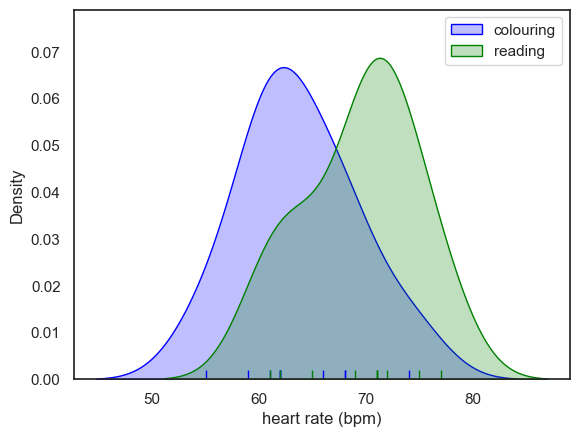

Pearson's r for colouring vs reading heart rate: 0.5259


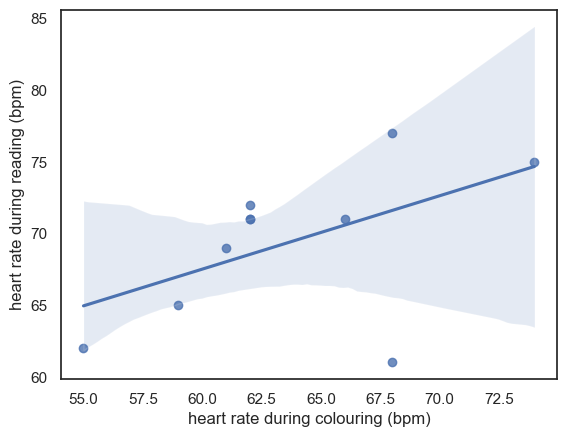

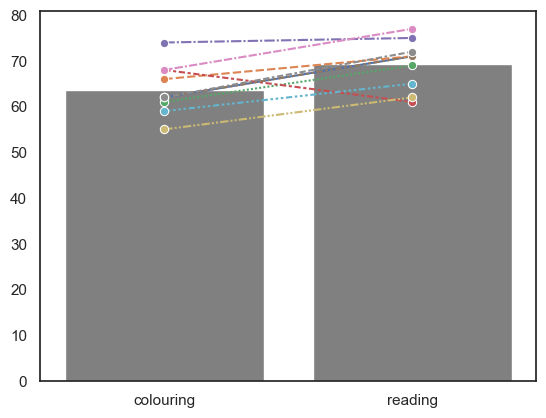

In [94]:
sns.kdeplot(data=heartRate, x='colouring', color='blue', fill=True)
sns.kdeplot(data=heartRate, x='reading', color='green', fill=True)
sns.rugplot(data=heartRate, x='colouring', color='blue')
sns.rugplot(data=heartRate, x='reading', color='green')

plt.xlabel('heart rate (bpm)')
plt.legend(['colouring', 'reading'])
plt.show()

sns.regplot(data=heartRate, x='colouring', y='reading')
plt.xlabel('heart rate during colouring (bpm)')
plt.ylabel('heart rate during reading (bpm)')
print("Pearson's r for colouring vs reading heart rate:", round(heartRate['colouring'].corr(heartRate['reading']), 4))
plt.show()

sns.lineplot(data=heartRate[["colouring", "reading"]].T, marker='o', legend=False)
sns.barplot(data=heartRate[["colouring", "reading"]], color='gray', errorbar=None)
plt.show()

From the two distributions (which both appear  normal) it seems that patients have their heartrate more decreased when colouring than when reading a book. There is also a slight correlation between the heartrates of each patient. In the last chart, each patient is visualised individually.

The sample dataset is very small, so it is hard to say whether this observation is also significant in the whole population.

**c)	This is a within-subjects or repeated-measures design. With reference to your graph, explain the advantages of a within-subjects design in this particular experiment.**


As stated before, there is an observer correlation between the patients heartrate during different activities. Variables outside of the experiment like lifestyle or age change the 'basal' heart rate of each patient, usually by a larger magnitude than the activities. If we had not measured 'within-subject', the difference in average heart rates would largely depend on the chosen cohort of patients doing each activity and more data would be required to negate this effect.

**d) Control condition**

*Why do you think the researcher chose to compare heart rate after one hour of colouring to heart rate after one hour of reading, as opposed to comparing heart rate before and after colouring?*


The activity of colouring involves other influences that could affect the heart rate, e.g. being calm and sitting down for an hour. Reading is a similar activity in this regard so is more suitable as a reference, as the only difference is the activity and not the configuration of the whole body.

**e)	Conduct three statistical tests of the researcher’s hypothesis, based on** 

*I.	Assumption of normality*

*II.	Permutation*

*III.	Ranked values*

*… in each case you should:*

* State the null and alternative hypothesis and the alpha value
* Report appropriate descriptive statistics for the test in question
* Carry out the test
* State the results of the test including the test statistic and p value. For the t-test, degrees of freedom should also be stated.
* Report your practical conclusion in plain English


**For I. (t) and II. (permutation) tests, I will define the following**:
- null hypothesis: the mean of the differences between bpm values after reading and colouring is zero, $μ_{colouring - reading} =  0$
- alternative hypothesis: the mean of the differences of bpm values after colouring and reading is lower than zero, $μ_{colouring - reading} < 0$ (lower tail)
- alpha value: 0.05

**For III. (rank based), I will define:**
- null hypothesis: the median difference in bpm between colouring and reading is zero
- alternative hypothesis: the median difference in bpm between colouring and reading is lower than zero
- alpha value: 0.05

In [95]:
ttest = stats.ttest_rel(heartRate.colouring,
                        heartRate.reading, 
                        alternative='less')

print("  I. Assumption of normality (related t test): p-value:", round(ttest.pvalue, 4), ", degrees of freedom:", ttest.df)

permutation = stats.permutation_test(
                (heartRate.colouring, heartRate.reading),
                lambda c, r: np.mean(c - r),
                permutation_type='samples', 
                alternative='less', 
                n_resamples=10000)

print(" II. Permutation test (paired):              p-value:", round(permutation.pvalue, 4))

ranked = stats.wilcoxon(
            heartRate.colouring,
            heartRate.reading,
            alternative='less')

print("III. Ranked values (Wilcoxon):               p-value:", round(ranked.pvalue, 4))

  I. Assumption of normality (related t test): p-value: 0.0035 , degrees of freedom: 9
 II. Permutation test (paired):              p-value: 0.0078
III. Ranked values (Wilcoxon):               p-value: 0.0068


For all three tests, we can conclude at α=0.05 sufficient evidence to reject the null hypothesis, even with just 10 data rows. This means that after colouring there is a statistically significant decrease in bpm in comparison to after reading.

**f) Assumption of normality**

*The use of the t-test rests on an assumption of normality. For a paired test, it is the **differences** that must be normally distributed for the t-test to be valid*

*Can you explain why it is the distribution of the differences, rather than the data, that is important?*

Because a paired t test is just a one-sample t test applied to the difference of the two distributions.

*Let's check if the distribution of differences is normal:*

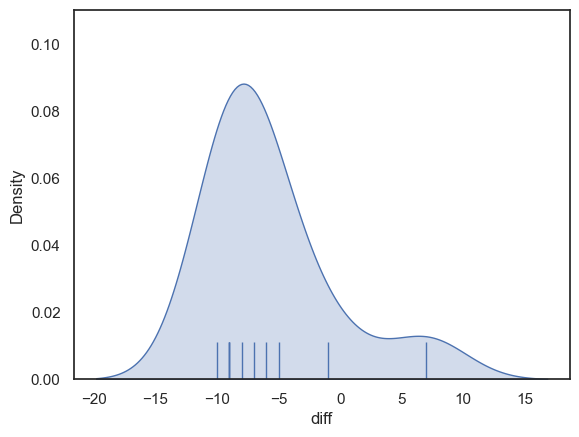

In [96]:
heartRate['diff']=heartRate.colouring-heartRate.reading
sns.kdeplot(heartRate['diff'], fill=True)
sns.rugplot(heartRate['diff'], height=0.1)
plt.show()

*It seems not - the differences have a distribution with positive skew (to be fair the sample size is too small to be really confident about this, but if unsure, it is better to avoid assuming normality)*

**g) Which statistical test do you think was the best choice for this dataset?**

The t test is probably not appropriate here, as the distribution is positively skewed and the sampling size is quite small.

Both a permutation and a ranked test are more appropriate as they do not rely on a normal distribution. It can be argued that the ranked test is slightly better despite its lower power, as it has higher resistance to outliers and skew.

## Question 3: Reaction times

*Two participants, A and B, perform a choice reaction time task in which they must press one of two buttons depending on whether a word was a real or made-up word*

*The data are provided in the file ChoiceRTs.csv. These are made-up data*

*Download the data file and load the data into a Pandas dataframe called ChoiceRTs:*

In [97]:
ChoiceRTs = pd.read_csv('https://raw.githubusercontent.com/jillxoreilly/StatsCourseBook_2024/main/data/ChoiceRTs.csv')
ChoiceRTs

,trialNumber,A,B
0,1,340.14,259.64
1,2,393.52,217.31
2,3,337.02,370.16
3,4,480.31,405.03
4,5,482.47,413.60
...,...,...,...
230,231,461.51,364.27
231,232,423.74,174.97
232,233,348.00,180.19
233,234,372.05,457.80


**a) Plot the data**

*Plot the data for each participant in a way that illustrates the distribution of reaction times for each person and allows them to be compared. Two subplots within a single figure would be a good choice here.*

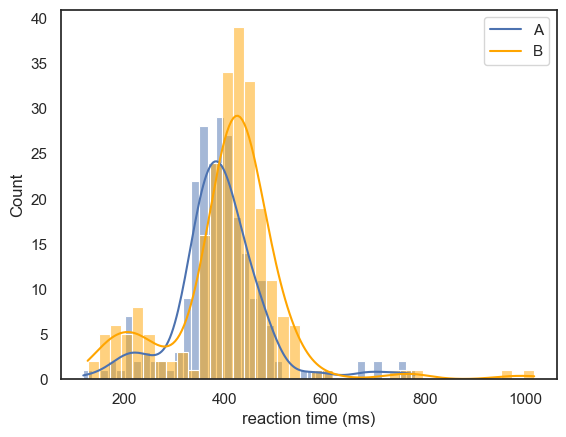

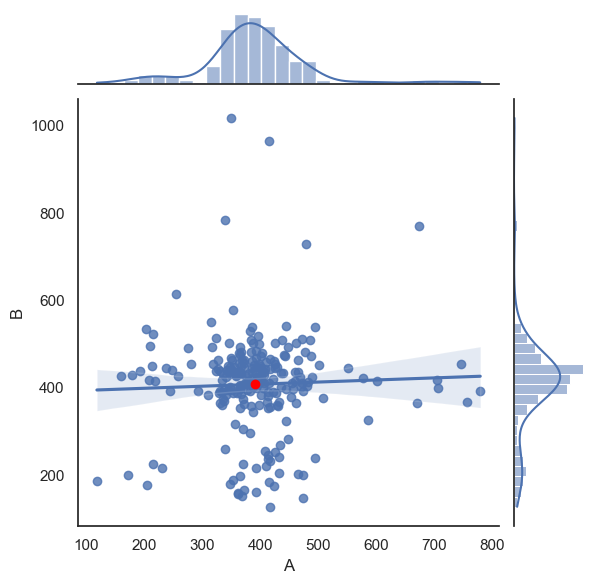

Pearson's r for A vs B's reaction times: 0.04


In [98]:
sns.histplot(ChoiceRTs, x='A', kde=True, bins=40)
sns.histplot(ChoiceRTs, x='B', kde=True, bins=40, color='orange')
plt.legend(['A', 'B'])
plt.xlabel('reaction time (ms)')
plt.show()

sns.jointplot(data=ChoiceRTs, x='A', y='B', kind='reg')
plt.plot(ChoiceRTs['A'].mean(), ChoiceRTs['B'].mean(), 'o', color='red')
plt.show()
print("Pearson's r for A vs B's reaction times:", round(ChoiceRTs['A'].corr(ChoiceRTs['B']), 2))


**c) Comment on the plot**


Both participants' reaction times show a negatively skewed distribution. Participant A's reaction times seem to be slightly faster. In the 2D plot a cluster of values can be observed around 400ms for both participants, with several outliers that vary widely. There is also very little correlation between the reaction times of the participants to the same stimuli.

**d) Data cleaning decision**

*The researcher decides that reaction times under 300ms (very fast responses) and over 700ms (very slow responses) should be excluded.*

*Do you think this is justified? Explain your answer.*

It can be argued that in the cases of the outliers another variable was at play, such as the readiness of the participants leading them to press the button before thinking about the word, or being distracted and pressing it too late.

It can also be observed statistically that most of the values are in a cluster with only a few outliers. ALso these outlier reaction times happen usually for only one of the two participants, leading to a 'cross' shape on the 2D plot and further reinforcing that they were just random errors caused influence the experiment's scope.

**e) Data cleaning implementation**

*Make a new dataframe called `ChoiceRTs_clean` with the data with RTs outside the range 300-700ms replaced by `NaN`*

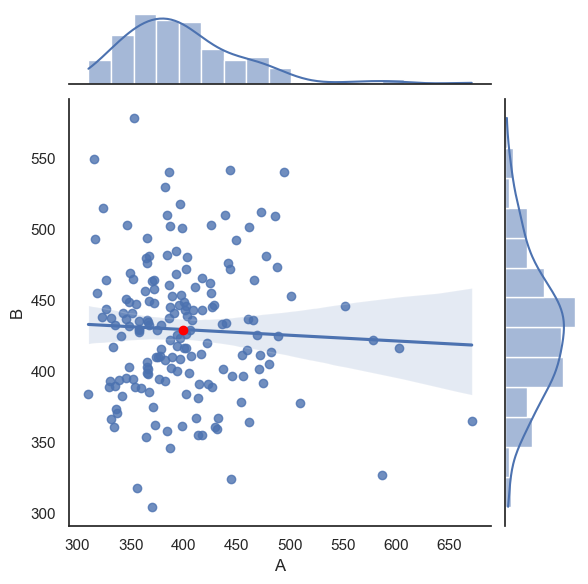

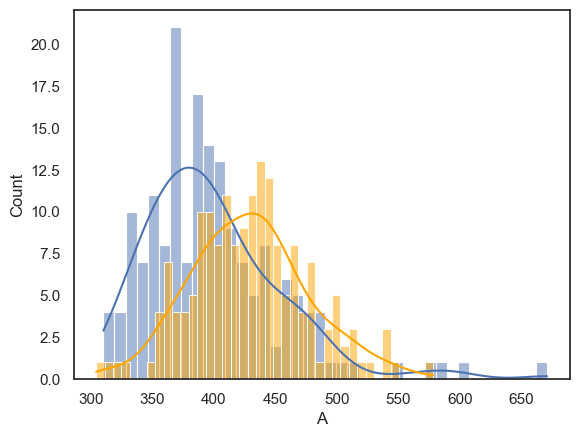

In [107]:
# *Make a new dataframe called `ChoiceRTs_clean` with the data with RTs outside the range 300-700ms replaced by `NaN`*

ChoiceRTs_clean = ChoiceRTs.copy()
ChoiceRTs_clean.loc[(ChoiceRTs_clean['A'] < 300) | (ChoiceRTs_clean['A'] > 700) |
                    (ChoiceRTs_clean['B'] < 300) | (ChoiceRTs_clean['B'] > 700)] = np.nan

sns.jointplot(data=ChoiceRTs_clean, x='A', y='B', kind='reg')
plt.plot(ChoiceRTs_clean['A'].mean(), ChoiceRTs_clean['B'].mean(), 'o', color='red')
plt.show()

sns.histplot(ChoiceRTs_clean, x='A', kde=True, bins=40)
sns.histplot(ChoiceRTs_clean, x='B', kde=True, bins=40, color='orange')
plt.show()

**f) Calculate the mean and sd of reaction time**

* before and 
* after excluding data outside the range 300-700 ms

*Comment on the difference in results*

In [104]:
print("mean:      A     |   B")
print("original ", round(ChoiceRTs['A'].mean(), 2), "|", round(ChoiceRTs['B'].mean(), 2))
print("cleaned  ", round(ChoiceRTs_clean['A'].mean(), 2), "|", round(ChoiceRTs_clean['B'].mean(), 2))

print("std:")
print("original ", round(ChoiceRTs['A'].std(), 2), " |", round(ChoiceRTs['B'].std(), 2))
print("cleaned  ", round(ChoiceRTs_clean['A'].std(), 2), " |", round(ChoiceRTs_clean['B'].std(), 2))


mean:      A     |   B
original  391.92 | 407.9
cleaned   399.38 | 429.25
std:
original  92.42  | 114.12
cleaned   56.41  | 47.96


Cleaning up has dramatically lowered the data standart deviation and also slightly moved the mean.

**g) Statistical test**

*In each case:*

i)	all the data

ii) the data with RTs outside the range 300-700ms excluded

*conduct a permutation test to determine whether there is a difference in the mean reaction time between the two participants*

**HINT you will need to replace the function `np.mean()` with `np.nanmean()` as np.mean() returns a NaN if any of the values being averaged are NaN**

**For both original and cleaned data:**
- null hypothesis: the mean of the differences between patient A and B's reaction time is zero, $μ_{A - B} = 0$ (lower tail)
- alternative hypothesis: , $μ_{A - B} \neq 0$ (two tailed)
- alpha: 0.025

In [106]:
original = stats.permutation_test(
                (ChoiceRTs['A'], ChoiceRTs['B']),
                lambda a, b: np.mean(a - b),
                permutation_type='samples', 
                alternative='two-sided', 
                n_resamples=10000)

print("Original data, permutation test (paired) - p-value:", round(original.pvalue, 4))


cleaned = stats.permutation_test(
                (ChoiceRTs_clean['A'], ChoiceRTs_clean['B']),
                lambda a, b: np.mean(a - b),
                permutation_type='samples',
                alternative='two-sided',
                n_resamples=10000)

print("Cleaned data, permutation test (paired) - p-value:", round(cleaned.pvalue, 4))

Original data, permutation test (paired) - p-value: 0.095
Cleaned data, permutation test (paired) - p-value: 0.0002


For the cleaned data, we can conclude at α=0.025 sufficient evidence to reject the null hypothesis. This means that the reactions times of patient A are lower than those of patient B with statistical significance.

**h) Comment on the difference in results when outliers are excluded**

Comment on the difference in results for the permutation test, with data outside the range 300-700ms omitted or not



The null hypothesis is not disproven without removing the outliers so it is vital to perform it. The p value after removing date outside of the 300-700 ms range is then very low, showing great significance

## Part 2 - More Revision

### Long vs wideform data

*Pandas dataframes can be in longform or wideform (definitions <a href='https://www.statology.org/long-vs-wide-data/'>here</a>. We have seen examples of both throughout the term. Let's check you are comfortable with using both formats.*

*Here are same data are provided in longform and wideform:*

In [122]:
heightsWideform = pd.read_csv('https://raw.githubusercontent.com/jillxoreilly/StatsCourseBook_2024/main/data/BrotherSisterData.csv')
heightsLongform = pd.read_csv('https://raw.githubusercontent.com/jillxoreilly/StatsCourseBook_2024/main/data/BrotherSisterDataLongform.csv')
heightsLongform

,familyID,sex,height
0,410119,Male,174
1,438181,Male,183
2,260033,Male,154
3,330754,Male,172
4,118173,Male,172
5,218511,Male,161
6,934515,Male,167
7,936244,Male,172
8,608784,Male,195
9,700114,Male,189


**a. Plot the data as a KDE plot (plot brothers and sisters as two separate KDEs)**

You might need to look back through the notes for examples of how to do this, or just try a few options to see what works.

<Axes: xlabel='height', ylabel='Density'>

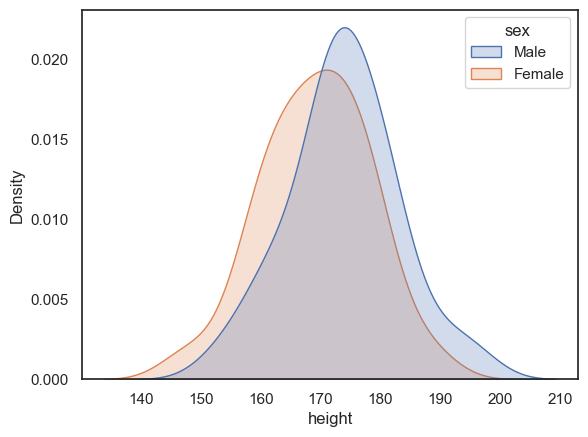

In [ ]:
# Your code here to plot the longform data
sns.kdeplot(heightsLongform, x='height', hue='sex', fill=True)

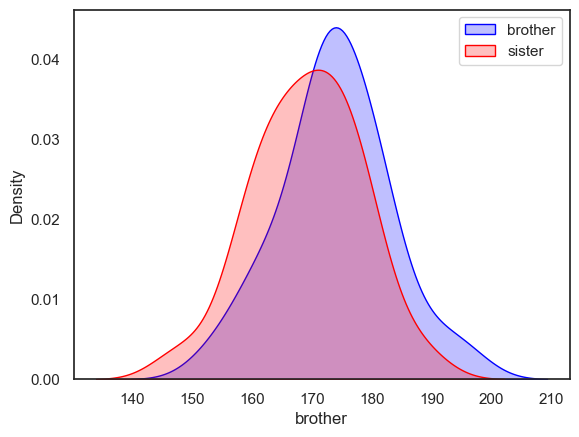

In [ ]:
# Your code here to plot the wideform data
sns.kdeplot(heightsWideform, x='sister', color='red', fill=True)
sns.kdeplot(heightsWideform, x='brother', color='blue', fill=True)
plt.legend(['brothers', 'sisters'])

**b. Plot the data as a scatterplot of brother vs sister's height**

*Let's do this for both longform and wideform data. **Use the function `sns.regplot()`** which adds the best fitting regression line (the straight line that best fits through the data points) and add the line x=y:*

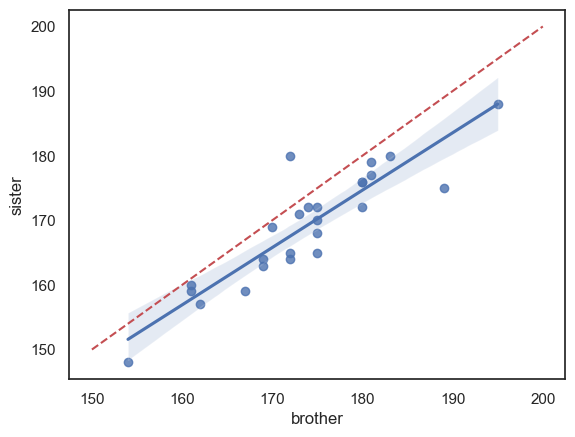

In [121]:
# Your code here to plot the wideform data
# use sns.regplot to make a sctterplot with regression line

sns.regplot(heightsWideform, x='brother', y='sister')

# add the line x=y as a red dashed line

plt.plot([150, 200], [150, 200], 'r--')


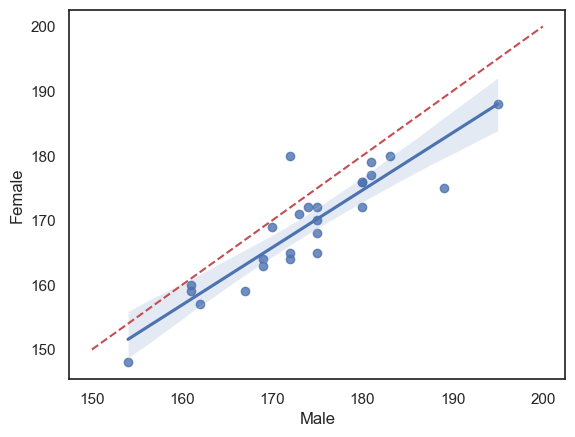

In [124]:
# Your code here to plot the longform data
# use sns.regplot to make a sctterplot with regression line
sns.regplot(heightsLongform.pivot(index="familyID", columns="sex", values="height"), x='Male', y='Female')

# add the line x=y as a red dashed line
plt.plot([150, 200], [150, 200], 'r--')

**c. Get the mean height for brothers and sisters separately**

*Do this for the longform and wideform dataframes*

In [125]:
# Your code to get the mean brother and sister heights from the wideform data
print("mean brother height:", round(heightsWideform['brother'].mean(), 2))
print("mean sister height:", round(heightsWideform['sister'].mean(), 2))

mean brother height: 173.8
mean sister height: 169.16


In [126]:
# Your code to get the mean brother and sister heights from the longform data
print("mean brother height:", round(heightsLongform[heightsLongform['sex'] == 'Male']['height'].mean(), 2))
print("mean sister height:", round(heightsLongform[heightsLongform['sex'] == 'Female']['height'].mean(), 2))

mean brother height: 173.8
mean sister height: 169.16


### Experimental design

**a. Paired design**

*i) What is a *paired* design (also called a *matched-pairs* design)?*

An experiment where we are looking at differences between linked pairs of values from each group, as opposed to looking just at two groups.

*ii) What are the advantages of a paired design (compared to a independent samples design?)*

The experiment can more precisely select for differences in data, as other influences are better mitigated by using a linked value as reference for each data point.

*iii) In a paired design, we are testing whether the average *difference* withing pairs is significantly different from zero. For example, is the difference between each brother and his own sister reliably positive (brothers are taller than sisters)?*

*Look at the scatterplot above. In this case, why is it particularly helpful to use a* paired *design rather than an independent samples design?*

For correlation, we want to observe the relationship of linked values so a paired design is necessary.

**b) Repeated measures design**

*A **repeated measures** design is a type of paired design.*

*i) Explain what is the difference between a paired design (in general) and a repeated measures design.*

A paired design involves two linked observed values, either from the same unit or from matched units (e.g., siblings). A repeated measures design is a specific case of paired design where the same unit is measured multiple times across time or different environmental conditions.

*ii) Give an example of a study in which a repeated measures design could be used (ie, 'if we wanted to test xxx, we could use a repeated measures design in which we measure.....')*

It can be used e.g. for tracking health data about people as they age, measuring values such as BMI or cognitive ability.

*iii) What potential pitfalls are there with repeated measures designs? How might they be mitigated?*

If a lot of time passes between measurements, a lot more can happen to influence the further outcomes outside of the influences we want to observe.

**d) Detailed example**

*A researcher hypothesises that men are taller than women:*

$\mathcal{H_o}$: the mean height of men is equal to that of women

$\mathcal{H_a}$: the mean height of men is greater than that of women

*She conducts two permutation tests on the brother-sister data as follows:*

In [129]:
# TEST 1:
def dMeans(x,y):
    return np.mean(x)-np.mean(y)

results1 = stats.permutation_test((heightsWideform.brother, heightsWideform.sister), 
                                   dMeans, permutation_type='independent')
results1

PermutationTestResult(statistic=np.float64(4.640000000000015), pvalue=np.float64(0.0766), null_distribution=array([-0.56,  0.24,  0.16, ...,  1.2 , -0.56, -3.36], shape=(9999,)))

In [130]:
# TEST 2:
def mDiff(x,y):
    return np.mean(x-y)

results2 = stats.permutation_test((heightsWideform.brother, heightsWideform.sister), 
                                   mDiff, permutation_type='samples')
results2

PermutationTestResult(statistic=np.float64(4.64), pvalue=np.float64(0.0002), null_distribution=array([ 0.24,  0.56,  0.08, ..., -2.64,  0.88, -0.96], shape=(9999,)))

**i) Which test was correct and why?**

(there was the wrong function inserted in TEST 2 which I fixed, but I assume that is not the question)

Both test can inferr a sensible conclusion, but as we have extra knowledge of the subjects being brothers and sisters, we can achieve a higher confidence by utilising the pairing. Test 2 does this and is thus more correct.

**ii) The p-value for Test 2 is smaller, why?**

As the test uses a difference within each sibling pair, the variance of this difference is smaller. In general it uses more information than test 1 which disregards siblings' relation.

**iii) In each case we specify a function to get the difference of means - what is the difference between `dMeans()` and `mDiff()`?**

dMeans has less assumptions and just compares the two populations

mDiff assumes pairs by first subtracting within them and then taking a mean of all the differences

**iv) The Test Statistic is the same for tests 1 and 2. Can you explain why?**

Because just in the equation, mean(a-b) = mean(a) - mean(b).

**v) The null distribution for tests 1 and 2 is quite different. Can you explain why?**

The null distributions are plotted for you here to help:

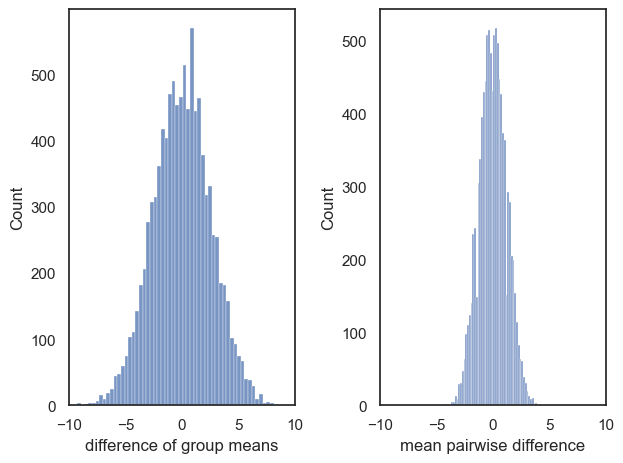

In [131]:
plt.subplot(1,2,1)
sns.histplot(results1.null_distribution)
plt.xlim([-10,10])
plt.xlabel('difference of group means')

plt.subplot(1,2,2)
sns.histplot(results2.null_distribution)
plt.xlim([-10,10])
plt.xlabel('mean pairwise difference')

plt.tight_layout()

The mean is the same as stated above, but the variance is smaller for test 2 as only siblings are paired with each other, thus the variance of their enviromental and family influences is minimised, leaving just the sex.

### One vs Two-tailed tests

*If we know the direction in which we expect an effect (men are taller than women) we can run a one-tailed test. Otherwise we must run a two-tailed test.*

*Load the following (made-up) data comparing the heights of female Psychology and female BMS students:*

In [132]:
heights = pd.read_csv('https://raw.githubusercontent.com/jillxoreilly/StatsCourseBook_2024/main/data/PsyBMSheights.csv')

*A researcher hypothesises that BMS students are taller than psychology students. She limits her analysis to female students:*
    
$\mathcal{H_o}$ The mean height of (female) psychology and BMS students are the same

$\mathcal{H_a}$ The mean height of (female) psychology students is less than the mean height of BMS students

*She decides to test at the $\alpha=0.05$ level*

**a) Is this a one or two tailed test?**

It is a one tailed test as she assumes a direction, but maybe it should not be given that there is little prior evidence for Psych < BMS.

**b) What's wrong in the following example?**

The researcher used a t-test to test her hypothesis as follows

In [133]:
stats.ttest_ind(heights.query('subject=="BMS"').height, heights.query('subject=="Psychology"').height, alternative='less')

TtestResult(statistic=np.float64(1.823852779167176), pvalue=np.float64(0.9627982812018988), df=np.float64(48.0))

What has she done wrong?

She specified the two groups in the wrong order, thus the result shows a p value for the opposite direction.

**c) Correct the mistake**

*Re-run the test, correcting the researcher's mistake*

In [134]:
stats.ttest_ind(heights.query('subject=="Psychology"').height, heights.query('subject=="BMS"').height, alternative='less')

TtestResult(statistic=np.float64(-1.823852779167176), pvalue=np.float64(0.03720171879810118), df=np.float64(48.0))

**d) Run a two-tailed test**

*Say the researcher had no a-priori hypothesis about which subject hahs taller students. Then she should have stated her hypotheses as follows, and run a two-tailed test*


$\mathcal{H_o}$ The mean height of (female) psychology and BMS students are the same

$\mathcal{H_o}$ The mean height of (female) psychology students is different from mean height of BMS students

*She still wishes to test at the $\alpha=0.05$ level**

**Run the test yourself**

In [135]:
stats.ttest_ind(heights.query('subject=="Psychology"').height, heights.query('subject=="BMS"').height, alternative='two-sided')

TtestResult(statistic=np.float64(-1.823852779167176), pvalue=np.float64(0.07440343759620235), df=np.float64(48.0))

*i) How does the $p$-value from the two tailed test relate to that of (correct version of) the one-tailed test above?*

It should be looked at as twice as large, as it represents the probability of the lesser and greater tail at the same time.
So about $0.0744 / 2 = 0.0372$

*ii) The two-tailed test is not significant at the 5% level whilst the one-tailed test was significant. Can you explain why?*
* Key terms for your answer are the *critical region* of the test and the *critical value* or *cut-off value*
* These were introduced in lectures but if you don't remember them, a quick good brings up several tutorials

In a two-tailed test, the significance level is split across both tails. This necessitates the the critical values to be more extreme (further from 0). The test statistic must thus bee larger in magnitude to fall into the critical region.

**e) "Peeking"**

*Why did the researcher think that BMS students would be taller in the first place? Because when she plotted the data to check for outliers (which is indeed correct procedure), she noticed that the BMS students looked taller:*

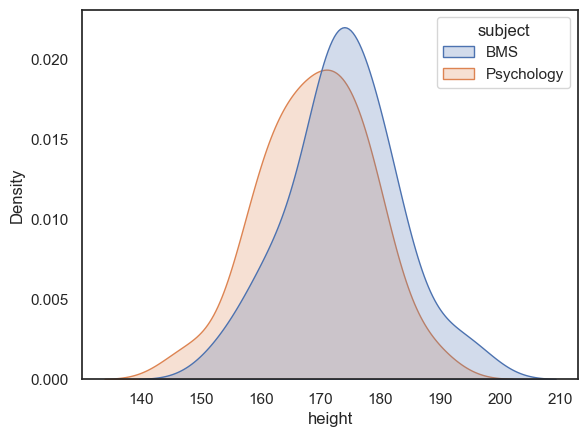

In [136]:
sns.kdeplot(data=heights, x='height', hue='subject', fill=True)
plt.show()

If the psychology students had looked taller, she would have done a one-tailed test in the other direction.

Using this approach (sometimes called "peeking" at the data) is wrong, because means that the chance of getting a 'significant' result if the null was true (the false positive rate) is double.

Can you explain why?

Because the assumption of a direction is biased by the data, which is a random sample that could go either way if we do not have external evidence for a specific direction.

*It is not wrong to inspect your data before running a test, but **your hypotheses (and in particular justification for a one-tailed test) should reflect predictions you would be able to make without seeing the particular sample of data**.*